In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

In [3]:
df = pd.read_excel(r"D:\Internship\thr_analysis\THROUGHPUT & CAPACITY STABILITY.xlsx")

In [4]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour

10th Percentile

In [5]:
plant_hour_thresholds = (
    df.groupby(['Plant', 'Hour'])['ProductionUnits']
      .quantile(0.10)
      .reset_index()
      .rename(columns={'ProductionUnits': 'PlantHour_Threshold'})
)

df = df.merge(plant_hour_thresholds, on=['Plant', 'Hour'], how='left')

Target Variable

In [6]:
df['LowOutputEvent'] = (df['ProductionUnits'] < df['PlantHour_Threshold']).astype(int)

Feature Selection

In [7]:
features = [
    "Temperature",
    "Vibration",
    "Pressure",
    "EnergyConsumption",
    "DefectCount",
    "MaintenanceFlag"
]

X = df[features]
y = df["LowOutputEvent"]

In [8]:
df.isnull().sum()

Timestamp              0
MachineID              0
Plant                  0
Temperature            0
Vibration              0
Pressure               0
EnergyConsumption      0
ProductionUnits        0
DefectCount            0
MaintenanceFlag        0
Hour                   0
PlantHour_Threshold    0
LowOutputEvent         0
dtype: int64

Train Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

SMOTE

In [10]:
sm = SMOTE(sampling_strategy='auto', random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE :", np.bincount(y_train_sm))

Before SMOTE: [14447  1553]
After SMOTE : [14447 14447]


Scale Data for SMOTE

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)

Train

In [12]:
model = RandomForestClassifier(
    n_estimators=250,
    random_state=42
)

model.fit(X_train_scaled, y_train_sm)

RandomForestClassifier(n_estimators=250, random_state=42)

Predict + Evaluate

In [13]:
y_pred = model.predict(X_test_scaled)

print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

F1 Score: 0.12252252252252252

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.82      0.86      3612
           1       0.09      0.18      0.12       388

    accuracy                           0.76      4000
   macro avg       0.50      0.50      0.49      4000
weighted avg       0.82      0.76      0.79      4000



SMOTE + XGBoost

In [14]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.4 MB/s eta 0:01:13
   ---------------------------------------- 1.0/101.7 MB 1.9 MB/s eta 0:00:53
    --------------------------------------- 1.6/101.7 MB 2.1 MB/s eta 0:00:47
    --------------------------------------- 2.1/101.7 MB 2.2 MB/s eta 0:00:46
   - -------------------------------------- 2.6/101.7 MB 2.2 MB/s eta 0:00:45
   - -------------------------------------- 3.1/101.7 MB 2.3 MB/s eta 0:00:43
   - -------------------------------------- 3.7/101.7 MB 2.4 MB/s eta 0:00:41
   - -------------------------------------- 4.7/101.7 MB 2.6 MB/s eta 0:00:38
   -- ------------------------------------- 5.2/101.7 MB 2.6 MB/s eta 0:00:37
   -- ------------------------------------- 5.8/101.7 MB 2.8 MB/s eta 0:00:35
   -- ------------------------------------- 6.8/101.7 MB 2.8 MB/s eta 0:00:34


In [15]:
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, f1_score
import numpy as np

SMOTE on scaling data

In [16]:
sm = SMOTE(sampling_strategy='auto', random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE :", np.bincount(y_train_sm))

Before SMOTE: [14447  1553]
After SMOTE : [14447 14447]


Scale after SMOTE

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

Compute Imbalance Ratio for XGBoost

In [18]:
ratio = (len(y_train_sm) - sum(y_train_sm)) / sum(y_train_sm)

Train XGBoost

In [19]:
model = XGBClassifier(
    max_depth=6,
    learning_rate=0.1,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,   # Key for imbalanced data
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

In [20]:
model.fit(X_train_scaled, y_train_sm)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

Predict and Evaluate

In [21]:
y_pred = model.predict(X_test_scaled)

print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

F1 Score: 0.14788312462731068

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.68      0.77      3612
           1       0.10      0.32      0.15       388

    accuracy                           0.64      4000
   macro avg       0.50      0.50      0.46      4000
weighted avg       0.82      0.64      0.71      4000



Feature Engineering

Temperature Energy Ratio

In [23]:
df["TempEnergyRatio"] = df["Temperature"] / (df["EnergyConsumption"] + 1)

Stress Index (Vibration * Pressure)

In [24]:
df["StressIndex"] = df["Vibration"] * df["Pressure"]

Energy per Unit

In [25]:
df["EnergyPerUnit"] = df["EnergyConsumption"] / (df["ProductionUnits"] + 1)

Rolling Averages (1 Hour Lag)

In [26]:
df["Temp_Roll1"] = df["Temperature"].rolling(2).mean().fillna(df["Temperature"])
df["Vib_Roll1"] = df["Vibration"].rolling(2).mean().fillna(df["Vibration"])
df["Press_Roll1"] = df["Pressure"].rolling(2).mean().fillna(df["Pressure"])

Rolling Averages (3 Hours Lag)

In [27]:
df["Temp_Roll3"] = df["Temperature"].rolling(4).mean().fillna(df["Temperature"])
df["Vib_Roll3"] = df["Vibration"].rolling(4).mean().fillna(df["Vibration"])
df["Press_Roll3"] = df["Pressure"].rolling(4).mean().fillna(df["Pressure"])

Interaction Term

In [28]:
df["TempVibInteraction"] = df["Temperature"] * df["Vibration"]

Features to use

In [29]:
features = [
    "Temperature", "Vibration", "Pressure",
    "EnergyConsumption", "DefectCount", "MaintenanceFlag",

    "TempEnergyRatio", "StressIndex", "EnergyPerUnit",
    "Temp_Roll1", "Vib_Roll1", "Press_Roll1",
    "Temp_Roll3", "Vib_Roll3", "Press_Roll3",
    "TempVibInteraction"
]

X = df[features]
y = df["LowOutputEvent"]

# Handle missing values
X = X.fillna(method="ffill").fillna(X.mean())

C:\Users\smrit\AppData\Local\Temp\ipykernel_13828\3082153820.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X = X.fillna(method="ffill").fillna(X.mean())


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [31]:
sm = SMOTE(sampling_strategy="auto", random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE :", np.bincount(y_train_sm))

Before SMOTE: [14447  1553]
After SMOTE : [14447 14447]


In [32]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)

In [33]:
ratio = (len(y_train_sm) - sum(y_train_sm)) / sum(y_train_sm)

model = XGBClassifier(
    max_depth=6,
    learning_rate=0.1,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train_scaled, y_train_sm)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [34]:
y_pred = model.predict(X_test_scaled)

print("\nF1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))


F1 Score: 0.9010989010989011

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3612
           1       0.86      0.95      0.90       388

    accuracy                           0.98      4000
   macro avg       0.93      0.97      0.94      4000
weighted avg       0.98      0.98      0.98      4000



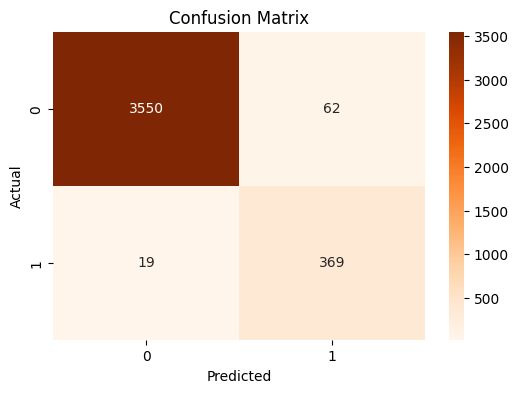

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

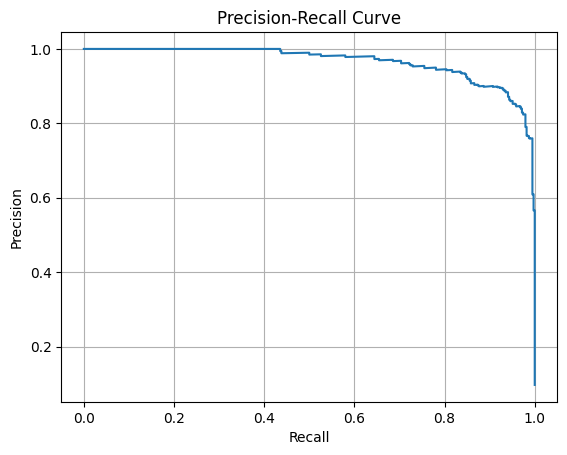

In [36]:
from sklearn.metrics import precision_recall_curve

y_scores = model.predict_proba(X_test_scaled)[:,1]
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()
plt.show()

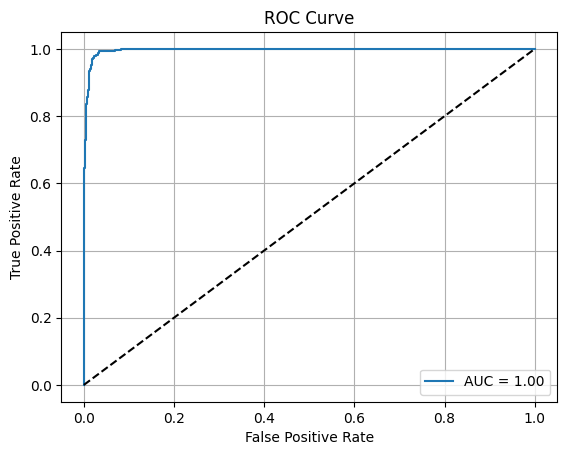

In [37]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()